In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

base = Path.cwd()
root = base if (base / "data").exists() else base.parent

matches = pd.read_csv(root / "data" / "processed" / "matches_clean.csv", parse_dates=["Date"])

fig_dir = root / "images"
fig_dir.mkdir(exist_ok=True)

print(matches.shape)
matches.head()

(1900, 23)


,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,HC,AC,HY,AY,HR,AR,TotalGoals,GoalDiff,Result,Target
0,2021-22,2021-08-13,Brentford,Arsenal,2,0,H,8,22,3,...,2,5,0,0,0,0,2,2,Home Win,0
1,2021-22,2021-08-14,Man United,Leeds,5,1,H,16,10,8,...,5,4,1,2,0,0,6,4,Home Win,0
2,2021-22,2021-08-14,Burnley,Brighton,1,2,A,14,14,3,...,7,6,2,1,0,0,3,-1,Away Win,2
3,2021-22,2021-08-14,Chelsea,Crystal Palace,3,0,H,13,4,6,...,5,2,0,0,0,0,3,3,Home Win,0
4,2021-22,2021-08-14,Everton,Southampton,3,1,H,14,6,6,...,6,8,2,0,0,0,4,2,Home Win,0


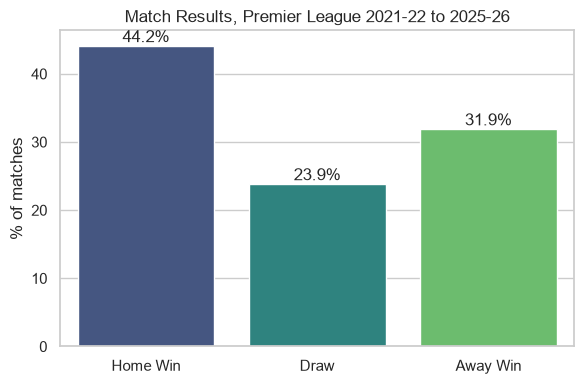

In [2]:
order = ["Home Win", "Draw", "Away Win"]
pct = matches["Result"].value_counts(normalize=True).reindex(order) * 100

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=pct.index, y=pct.values, hue=pct.index, palette="viridis", legend=False)
for i, v in enumerate(pct.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.title("Match Results, Premier League 2021-22 to 2025-26")
plt.ylabel("% of matches")
plt.xlabel("")
plt.tight_layout()
plt.savefig(fig_dir / "01_result_distribution.png", dpi=150)
plt.show()

Avg home goals: 1.60 | Avg away goals: 1.33
Avg total goals per match: 2.93


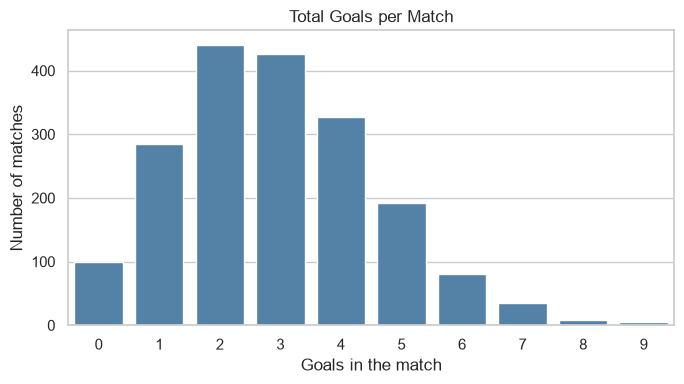

In [3]:
print(f"Avg home goals: {matches['FTHG'].mean():.2f} | Avg away goals: {matches['FTAG'].mean():.2f}")
print(f"Avg total goals per match: {matches['TotalGoals'].mean():.2f}")

plt.figure(figsize=(7, 4))
sns.countplot(x="TotalGoals", data=matches, color="steelblue")
plt.title("Total Goals per Match")
plt.xlabel("Goals in the match")
plt.ylabel("Number of matches")
plt.tight_layout()
plt.savefig(fig_dir / "02_goals_distribution.png", dpi=150)
plt.show()

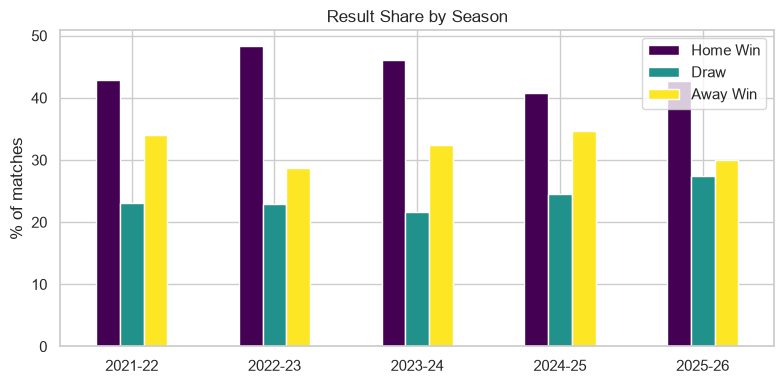

Result,Home Win,Draw,Away Win
Season,,,
2021-22,42.9,23.2,33.9
2022-23,48.4,22.9,28.7
2023-24,46.1,21.6,32.4
2024-25,40.8,24.5,34.7
2025-26,42.6,27.4,30.0


In [4]:
season_res = (matches.groupby("Season")["Result"]
              .value_counts(normalize=True)
              .unstack()
              .reindex(columns=order) * 100)

season_res.plot(kind="bar", figsize=(8, 4), colormap="viridis", rot=0)
plt.title("Result Share by Season")
plt.ylabel("% of matches")
plt.xlabel("")
plt.legend(title="")
plt.tight_layout()
plt.savefig(fig_dir / "03_home_advantage_by_season.png", dpi=150)
plt.show()

season_res.round(1)

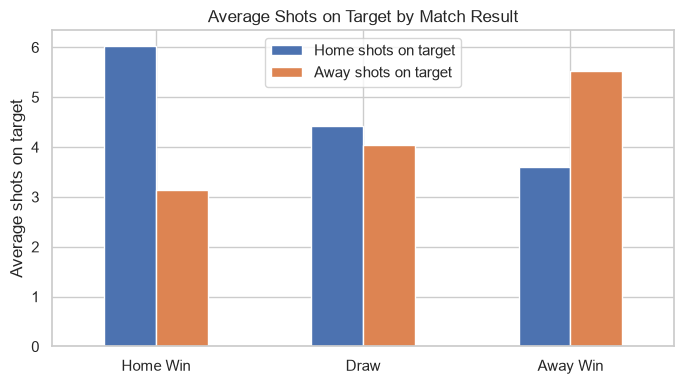

,Home shots on target,Away shots on target
Result,,
Home Win,6.04,3.14
Draw,4.43,4.05
Away Win,3.60,5.53


In [5]:
sot = matches.groupby("Result")[["HST", "AST"]].mean().reindex(order)
sot.columns = ["Home shots on target", "Away shots on target"]

sot.plot(kind="bar", figsize=(7, 4), rot=0)
plt.title("Average Shots on Target by Match Result")
plt.ylabel("Average shots on target")
plt.xlabel("")
plt.tight_layout()
plt.savefig(fig_dir / "04_shots_on_target_vs_result.png", dpi=150)
plt.show()

sot.round(2)

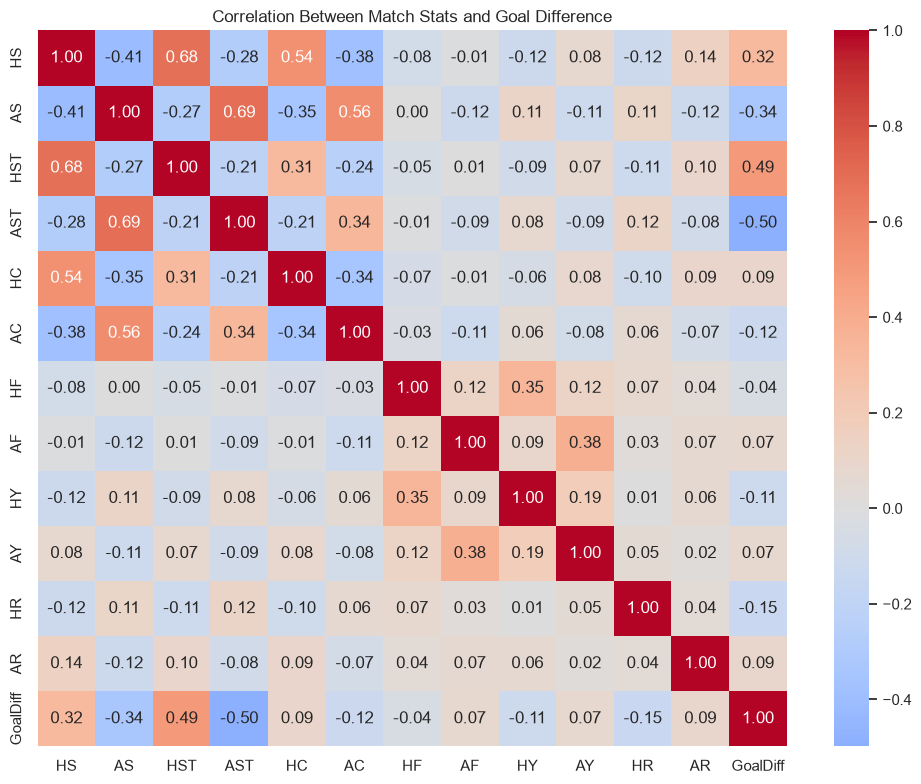

In [6]:
num_cols = ["HS", "AS", "HST", "AST", "HC", "AC", "HF", "AF",
            "HY", "AY", "HR", "AR", "GoalDiff"]

plt.figure(figsize=(10, 8))
sns.heatmap(matches[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Match Stats and Goal Difference")
plt.tight_layout()
plt.savefig(fig_dir / "05_correlation_heatmap.png", dpi=150)
plt.show()

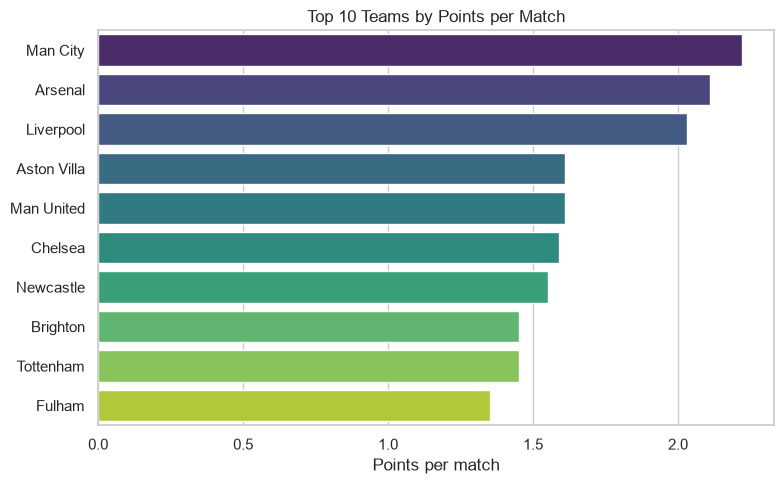

,Matches,Points,PointsPerMatch
Team,,,
Man City,190,422,2.22
Arsenal,190,401,2.11
Liverpool,190,385,2.03
Aston Villa,190,305,1.61
Man United,190,306,1.61
Chelsea,190,302,1.59
Newcastle,190,295,1.55
Brighton,190,275,1.45
Tottenham,190,276,1.45


In [7]:
home = matches.assign(Team=matches["HomeTeam"], Points=matches["Target"].map({0: 3, 1: 1, 2: 0}))
away = matches.assign(Team=matches["AwayTeam"], Points=matches["Target"].map({2: 3, 1: 1, 0: 0}))
games = pd.concat([home[["Team", "Points"]], away[["Team", "Points"]]])

table = games.groupby("Team").agg(Matches=("Points", "count"), Points=("Points", "sum"))
table["PointsPerMatch"] = (table["Points"] / table["Matches"]).round(2)

# Only teams with at least 2 seasons of data (76+ matches)
top = table[table["Matches"] >= 76].sort_values("PointsPerMatch", ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top["PointsPerMatch"], y=top.index, hue=top.index, palette="viridis", legend=False)
plt.title("Top 10 Teams by Points per Match")
plt.xlabel("Points per match")
plt.ylabel("")
plt.tight_layout()
plt.savefig(fig_dir / "06_top_teams.png", dpi=150)
plt.show()

top